# 10 - Significance Tests and Confidence Intervals

**Goal:** find out which differences in the earlier notebooks are real and which could be noise. Every earlier number was a single mean over a handful of test batches,
some of them tiny. Here we attach uncertainty to the headline results and test the pre-declared comparisons.

> **Beginner note - the tools**
> * **Confidence interval (CI):** a range that plausibly contains the true score. A 95% CI that is wide means "we do not know the score precisely".
> * **Bootstrap:** to see how much a score would wobble with different data, re-draw the test samples *with replacement* many times (here 2,000), recompute the score each time, and
>   read the spread. **Paired:** every model is scored on exactly the same re-drawn samples, so the *difference* between two models is measured fairly.
> * **Why two levels?** Samples inside one batch are near-identical "twins" (notebook 01), so wobbling only the samples makes intervals unrealistically narrow.
>   Our **primary (two-level) interval also re-draws whole batches**, which captures the large batch-to-batch differences. The **conditional** interval (samples only) is shown as secondary.
> * **Pre-declared verdict for a difference A - B:** **clear** if the two-level interval excludes 0; **suggestive** if only the conditional interval does; otherwise **inconclusive**.
> * **p-value** (Wilcoxon signed-rank on the per-batch differences) and **Holm correction** for running many comparisons. With only 7 (P1) or 9 (P3) test batches no p-value can be very small
>   (the smallest possible is 0.016 for 7 batches), so we rely on effect sizes and intervals.
> * **Friedman test + Nemenyi critical difference:** a rank-based test for "are all these models equivalent?" across test batches, and the smallest rank gap that counts as a real difference.
> * **McNemar test:** compares two models on the *same samples* (who is right where the other is wrong). It treats samples as independent, so it is optimistic here; shown as supplementary only.

Everything uses the exact predictions of the earlier steps (defaults, tuned settings, stacking, pre-declared feature selection, pre-declared mitigation); nothing is re-tuned.
The point estimate is the **unweighted mean macro-F1 over the test batches** (P1: batches 4-10; P3: batches 2-10), the same as in all earlier notebooks.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import load_all
from src.stats import (per_batch_f1, bootstrap_f1, two_level_means, percentile_ci, compare, mcnemar_exact, friedman_nemenyi, holm)
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()
N_BOOT = 2000
P = {"P1": pd.read_csv(RES / "10_predictions_P1.csv"), "P3": pd.read_csv(RES / "10_predictions_P3.csv")}
MASK = {"P1": batch >= 4, "P3": batch >= 2}; BATCHES = {"P1": list(range(4, 11)), "P3": list(range(2, 11))}
YT = {p: y[MASK[p]] for p in P}; BT = {p: batch[MASK[p]] for p in P}
print({p: d.shape for p, d in P.items()})

{'P1': (10635, 74), 'P3': (13465, 23)}


## 0. Validation: do the stored predictions reproduce every earlier result?

For each stored configuration we recompute the per-batch macro-F1 from its predictions and compare it with the value reported by the earlier notebook (04 defaults, 05 stacking,
07 tuned, 08 mitigation, 09 feature selection). If this check fails, nothing below can be trusted.

In [2]:
r04 = pd.read_csv(RES / "04_baselines_results.csv"); r05 = pd.read_csv(RES / "05_stacking_results.csv"); r07 = pd.read_csv(RES / "07_tuned_test_results.csv")
r08 = pd.read_csv(RES / "08_mitigation_results.csv"); r09 = pd.read_csv(RES / "09_selection_results.csv")
def reference(key):
    proto, model, variant, kind = key.split("|")
    if kind == "default" or (proto == "P3" and kind == "baseline"):
        src = r05 if model.startswith("Stacking") else r04
        d = src[(src.protocol == proto) & (src.model == model) & (src.variant == variant)]
    elif kind == "tuned": d = r07[(r07.protocol == "P1") & (r07.model == model) & (r07.variant == variant)]
    elif kind.startswith("sel-"): d = r09[(r09.rule == kind[4:]) & (r09.frac == 0.5) & (r09.seed == 0) & (r09.model == model)]
    else: d = r08[(r08.protocol == proto) & (r08.model == model) & (r08.variant == variant) & (r08.method == kind)]
    return d.sort_values("test_batch").set_index("test_batch").macro_f1

rows = []
for proto in P:
    for key in P[proto].columns:
        mine = pd.Series(per_batch_f1(YT[proto], P[proto][key].to_numpy(), BT[proto], BATCHES[proto]), index=BATCHES[proto]); ref = reference(key)
        rows.append({"protocol": proto, "kind": key.split("|")[3] if "default" not in key and "baseline" not in key else "default/baseline", "key": key, "max_abs_diff": float((mine - ref.reindex(mine.index)).abs().max())})
chk = pd.DataFrame(rows)
display(chk.groupby(["protocol", "kind"]).agg(configurations=("key", "size"), worst_difference=("max_abs_diff", "max")))
print("worst difference over all", len(chk), "stored configurations:", f"{chk.max_abs_diff.max():.2e}")

configurations  worst_difference
protocol kind                                                  
P1       batch-std                          8      2.220446e-16
         coral                              8      1.110223e-16
         default/baseline                  28      2.220446e-16
         sel-balanced                       3      1.665335e-16
         sel-discriminative                 3      1.387779e-16
         sel-stable                         3      1.110223e-16
         tuned                             21      2.220446e-16
P3       batch-std                          2      2.220446e-16
         coral                              2      1.110223e-16
         default/baseline                   7      2.220446e-16
         recency-h1                         2      1.110223e-16
         recency-h2                         2      2.220446e-16
         window-1                           2      1.110223e-16
         window-2                           2      2.220446e-16
         window-2 + batch-std               2      3.330669e-16
         window-3                           2      1.110223e-16

worst difference over all 97 stored configurations: 3.33e-16


## 1. Headline results with 95% confidence intervals (P1: train on batches 1-3, test on 4-10)

Mean macro-F1 over the 7 test batches with the **two-level** interval (primary) and the **conditional** interval (secondary).

,configuration,macro-F1,CI two-level lo,CI two-level hi,CI conditional lo,CI conditional hi
0,SVM|raw|default,0.690,0.567,0.821,0.679,0.699
1,kNN|raw|default,0.609,0.528,0.697,0.593,0.621
2,Random Forest|raw|default,0.518,0.364,0.672,0.504,0.529
3,Gradient Boosting|raw|default,0.495,0.327,0.687,0.481,0.507
4,AdaBoost|raw|default,0.488,0.340,0.658,0.472,0.501
5,Naive Bayes|raw|default,0.461,0.266,0.661,0.448,0.473
6,Decision Tree|raw|default,0.408,0.267,0.557,0.393,0.421
7,SVM|raw|tuned,0.670,0.547,0.809,0.659,0.680
8,Stacking (random CV)|PCA|default,0.673,0.586,0.787,0.661,0.684
9,Stacking (batch CV)|raw|default,0.540,0.416,0.639,0.525,0.553


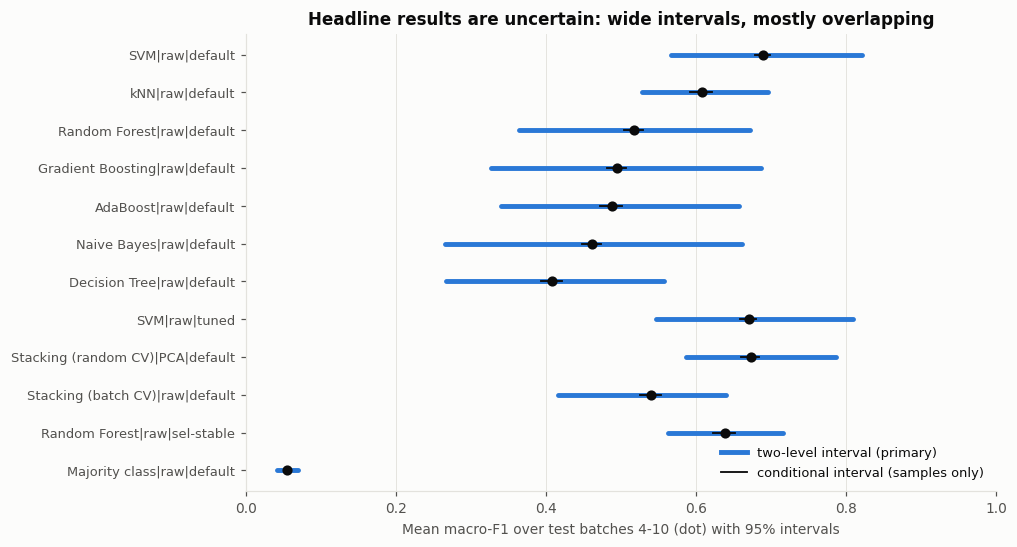

In [3]:
def boot(proto, keys):
    F, names = bootstrap_f1(YT[proto], {k: P[proto][k].to_numpy() for k in keys}, BT[proto], BATCHES[proto], n_boot=N_BOOT, seed=42)
    point = {k: per_batch_f1(YT[proto], P[proto][k].to_numpy(), BT[proto], BATCHES[proto]) for k in keys}
    return F, names, point

head_keys = [f"P1|{m}|raw|default" for m in ["SVM", "kNN", "Random Forest", "Gradient Boosting", "AdaBoost", "Naive Bayes", "Decision Tree"]] + \
            ["P1|SVM|raw|tuned", "P1|Stacking (random CV)|PCA|default", "P1|Stacking (batch CV)|raw|default", "P1|Random Forest|raw|sel-stable", "P1|Majority class|raw|default"]
F1_, names1, point1 = boot("P1", head_keys)
T = two_level_means(F1_); rows = []
for i, k in enumerate(names1):
    two, cond = percentile_ci(T[:, i]), percentile_ci(F1_[:, :, i].mean(axis=1))
    rows.append({"configuration": k.replace("P1|", ""), "macro-F1": point1[k].mean(), "CI two-level lo": two[0], "CI two-level hi": two[1], "CI conditional lo": cond[0], "CI conditional hi": cond[1]})
head = pd.DataFrame(rows); head.to_csv(RES / "10_headline_ci_P1.csv", index=False); display(head.round(3))

fig, ax = plt.subplots(figsize=(8.8, 5.4)); h = head.iloc[::-1].reset_index(drop=True)
for i, r in h.iterrows():
    ax.plot([r["CI two-level lo"], r["CI two-level hi"]], [i, i], color=SERIES[0], lw=3.2, solid_capstyle="round", zorder=2)
    ax.plot([r["CI conditional lo"], r["CI conditional hi"]], [i, i], color=INK, lw=1.2, zorder=3)
    ax.scatter(r["macro-F1"], i, color=INK, s=32, zorder=4)
ax.set_yticks(range(len(h))); ax.set_yticklabels(h.configuration, fontsize=8.5); ax.set_xlim(0, 1); ax.grid(axis="y", visible=False)
ax.set_xlabel("Mean macro-F1 over test batches 4-10 (dot) with 95% intervals"); ax.set_title("Headline results are uncertain: wide intervals, mostly overlapping")
ax.plot([], [], color=SERIES[0], lw=3.2, label="two-level interval (primary)"); ax.plot([], [], color=INK, lw=1.2, label="conditional interval (samples only)"); ax.legend(frameon=False, fontsize=8.5, loc="lower right")
fig.savefig(FIG / "37_headline_confidence_intervals.png"); plt.show()

## 2. Pre-declared pairwise comparisons

The list below was fixed before any interval was computed. `diff` = A minus B in mean macro-F1; `A>B` = number of test batches on which A is better.
`p` is the exact Wilcoxon p-value of the per-batch differences; `p (Holm)` corrects for the whole family. `McNemar p` uses pooled samples and is optimistic (supplementary).

In [4]:
fam = []
add = lambda family, proto, a, b, label: fam.append((family, proto, a, b, label))
for m in ["kNN", "Random Forest", "Gradient Boosting", "AdaBoost", "Naive Bayes", "Decision Tree"]:
    add("1 default models (P1)", "P1", "P1|SVM|raw|default", f"P1|{m}|raw|default", f"SVM vs {m}")
add("2 tuning (P1)", "P1", "P1|SVM|raw|tuned", "P1|SVM|raw|default", "SVM raw: tuned vs default")
add("2 tuning (P1)", "P1", "P1|AdaBoost|raw|tuned", "P1|AdaBoost|raw|default", "AdaBoost raw: tuned vs default")
add("3 stacking (P1)", "P1", "P1|Stacking (batch CV)|raw|default", "P1|SVM|raw|default", "Stacking (batch CV) vs SVM")
add("3 stacking (P1)", "P1", "P1|Stacking (random CV)|PCA|default", "P1|SVM|raw|default", "Stacking (random CV, PCA) vs SVM")
add("3 stacking (P1)", "P1", "P1|Stacking (batch CV)|raw|default", "P1|Stacking (random CV)|raw|default", "Stacking: batch CV vs random CV")
for m in ["SVM", "Random Forest", "kNN"]:
    for rule in ["stable", "discriminative"]:
        add("4 feature selection (P1)", "P1", f"P1|{m}|raw|sel-{rule}", f"P1|{m}|raw|default", f"{m}: {rule} half vs all features")
for m in ["SVM", "Random Forest"]:
    for meth in ["batch-std", "coral"]:
        add("5 label-free mitigation (P1)", "P1", f"P1|{m}|raw|{meth}", f"P1|{m}|raw|default", f"{m}: {meth} vs plain")
for m in ["SVM", "Random Forest"]:
    for meth in ["window-1", "window-2", "window-3", "recency-h1", "recency-h2", "batch-std", "coral", "window-2 + batch-std"]:
        add(f"6 rolling mitigation (P3, {m})", "P3", f"P3|{m}|raw|{meth}", f"P3|{m}|raw|baseline", f"{m}: {meth} vs retrain on all")

results = []
for proto in ["P1", "P3"]:
    sub = [f for f in fam if f[1] == proto]; keys = sorted({k for f in sub for k in (f[2], f[3])})
    F, names, point = boot(proto, keys)
    for family, _, a, b, label in sub:
        c = compare(F, names, a, b, point)
        mc = mcnemar_exact(YT[proto], P[proto][a].to_numpy(), P[proto][b].to_numpy())
        results.append({"family": family, "comparison": label, "diff": c["diff"], "ci2_lo": c["ci_two_level"][0], "ci2_hi": c["ci_two_level"][1],
                        "ci1_lo": c["ci_conditional"][0], "ci1_hi": c["ci_conditional"][1], "A>B": f"{c['batches_A_better']}/{c['n_batches']}",
                        "p": c["wilcoxon_p"], "McNemar p": mc["p"], "verdict": c["verdict"]})
comp = pd.DataFrame(results); comp["p (Holm)"] = holm(comp.p.to_numpy()); comp.to_csv(RES / "10_pairwise_comparisons.csv", index=False)
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 100)
display(comp[["family", "comparison", "diff", "ci2_lo", "ci2_hi", "A>B", "p", "p (Holm)", "McNemar p", "verdict"]].round(3))
print(comp.verdict.value_counts().to_dict(), "| smallest Holm-adjusted p:", round(comp["p (Holm)"].min(), 3))

,family,comparison,diff,ci2_lo,ci2_hi,A>B,p,p (Holm),McNemar p,verdict
0,1 default models (P1),SVM vs kNN,0.081,0.021,0.139,6/7,0.078,1.000,0.000,clear
1,1 default models (P1),SVM vs Random Forest,0.172,0.088,0.259,7/7,0.016,0.531,0.000,clear
2,1 default models (P1),SVM vs Gradient Boosting,0.194,0.100,0.308,7/7,0.016,0.531,0.000,clear
3,1 default models (P1),SVM vs AdaBoost,0.201,0.139,0.275,7/7,0.016,0.531,0.000,clear
4,1 default models (P1),SVM vs Naive Bayes,0.228,0.121,0.353,7/7,0.016,0.531,0.000,clear
5,1 default models (P1),SVM vs Decision Tree,0.281,0.178,0.381,7/7,0.016,0.531,0.000,clear
6,2 tuning (P1),SVM raw: tuned vs default,-0.019,-0.073,0.020,4/7,0.938,1.000,1.000,suggestive
7,2 tuning (P1),AdaBoost raw: tuned vs default,0.039,-0.060,0.128,4/7,0.469,1.000,0.000,suggestive
8,3 stacking (P1),Stacking (batch CV) vs SVM,-0.150,-0.238,-0.054,1/7,0.047,1.000,0.000,clear
9,3 stacking (P1),"Stacking (random CV, PCA) vs SVM",-0.016,-0.086,0.048,3/7,0.812,1.000,0.005,suggestive


{'clear': 24, 'suggestive': 12, 'inconclusive': 1} | smallest Holm-adjusted p: 0.145


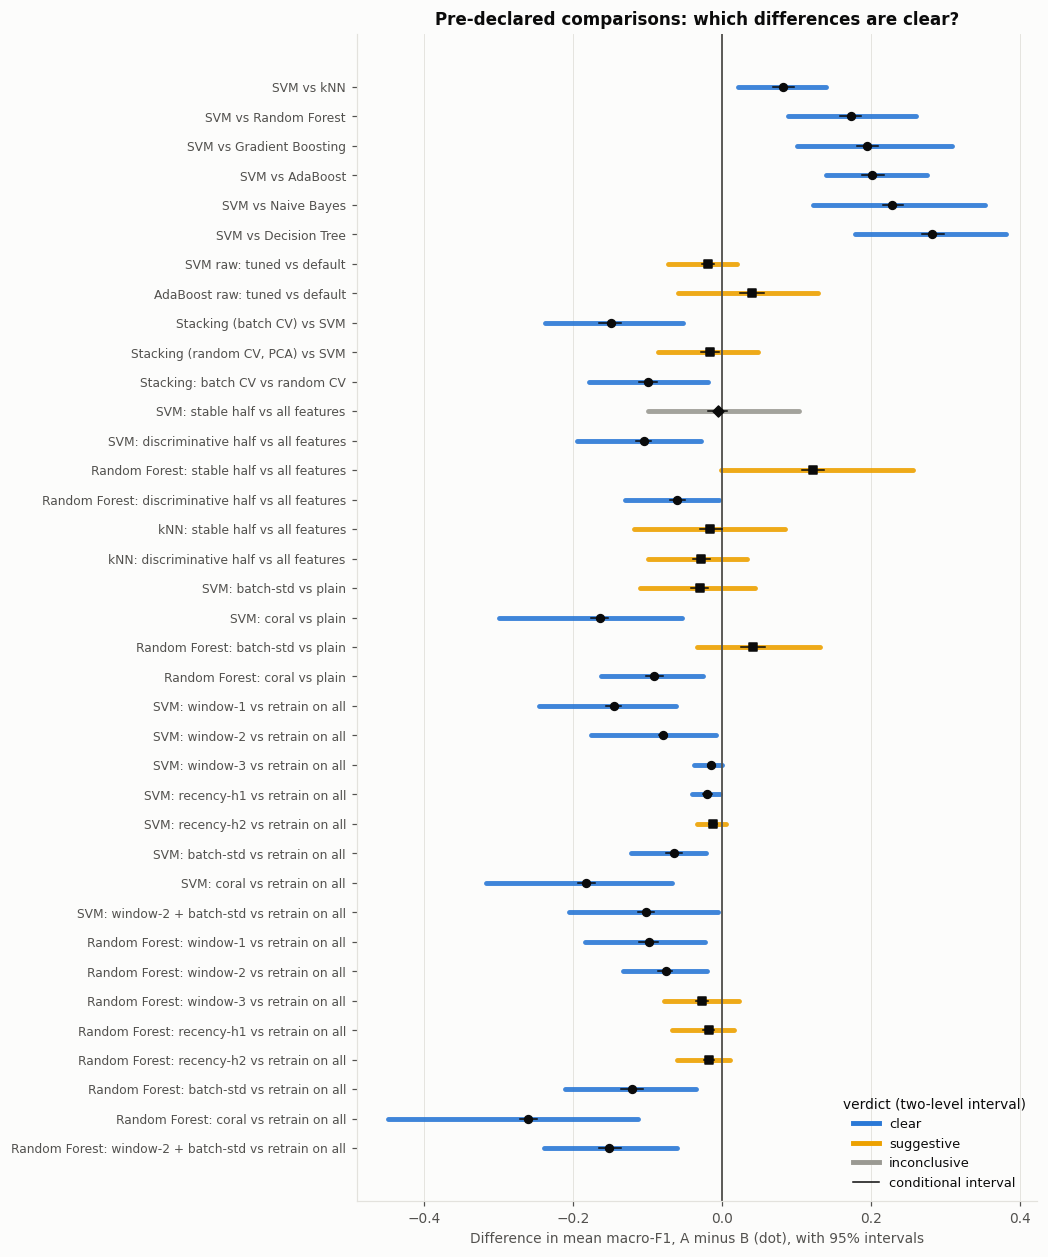

In [5]:
col = {"clear": SERIES[0], "suggestive": SERIES[3], "inconclusive": "#9a9992"}; mk = {"clear": "o", "suggestive": "s", "inconclusive": "D"}
d = comp.iloc[::-1].reset_index(drop=True); fig, ax = plt.subplots(figsize=(9.6, 11.5))
for i, r in d.iterrows():
    ax.plot([r.ci2_lo, r.ci2_hi], [i, i], color=col[r.verdict], lw=3.2, solid_capstyle="round", zorder=2, alpha=0.9)
    ax.plot([r.ci1_lo, r.ci1_hi], [i, i], color=INK, lw=1.0, zorder=3)
    ax.scatter(r["diff"], i, color=INK, marker=mk[r.verdict], s=26, zorder=4)
ax.axvline(0, color=INK2, lw=1.2); ax.set_yticks(range(len(d))); ax.set_yticklabels(d.comparison, fontsize=8); ax.grid(axis="y", visible=False)
ax.set_xlabel("Difference in mean macro-F1, A minus B (dot), with 95% intervals"); ax.set_title("Pre-declared comparisons: which differences are clear?")
for v in ["clear", "suggestive", "inconclusive"]: ax.plot([], [], color=col[v], lw=3.2, label=v)
ax.plot([], [], color=INK, lw=1.0, label="conditional interval"); ax.legend(frameon=False, fontsize=8.5, loc="lower right", title="verdict (two-level interval)")
fig.tight_layout(); fig.savefig(FIG / "38_pairwise_differences.png"); plt.show()

## 3. Are the models different at all? Friedman test and Nemenyi critical difference

Each test batch is one "block"; models are ranked on every batch (1 = best). The **critical difference (CD)** is the smallest gap in average rank that counts as a real difference;
models joined by a bar are *not* significantly different. Models: the seven defaults on raw features (P1: 7 batches; P3: 9 batches).

P1: Friedman chi2 = 24.06, p = 0.0005, blocks = 7, Nemenyi CD = 3.40


,SVM,kNN,Random Forest,Gradient Boosting,AdaBoost,Naive Bayes,Decision Tree
average rank (1 = best),1.14,2.86,3.71,4.29,4.71,5.14,6.14


P3: Friedman chi2 = 34.00, p = 0.0000, blocks = 9, Nemenyi CD = 3.00


,SVM,Random Forest,kNN,Gradient Boosting,Decision Tree,AdaBoost,Naive Bayes
average rank (1 = best),2.0,2.11,2.89,4.11,4.89,5.89,6.11


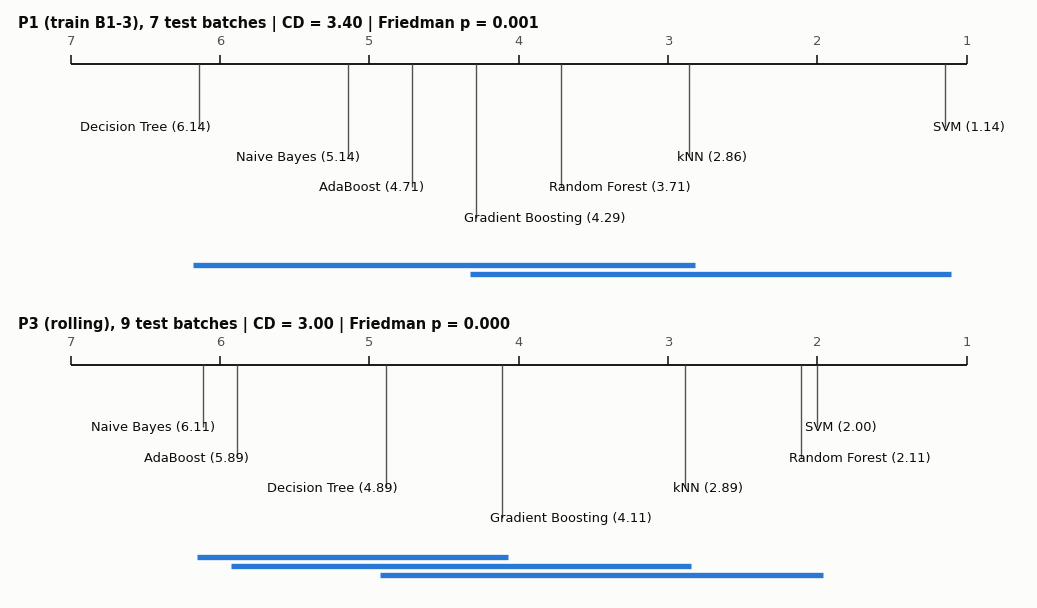

In [6]:
MODELS = ["SVM", "kNN", "Random Forest", "Gradient Boosting", "AdaBoost", "Naive Bayes", "Decision Tree"]
cd_res = {}
for proto, kind in [("P1", "default"), ("P3", "baseline")]:
    M = np.column_stack([per_batch_f1(YT[proto], P[proto][f"{proto}|{m}|raw|{kind}"].to_numpy(), BT[proto], BATCHES[proto]) for m in MODELS])
    cd_res[proto] = friedman_nemenyi(M, MODELS)
    r = cd_res[proto]; print(f"{proto}: Friedman chi2 = {r['chi2']:.2f}, p = {r['p']:.4f}, blocks = {r['n_blocks']}, Nemenyi CD = {r['cd']:.2f}")
    display(pd.Series(r["avg_rank"], index=MODELS, name="average rank (1 = best)").sort_values().round(2).to_frame().T)
pd.DataFrame({p: pd.Series(r["avg_rank"], index=MODELS) for p, r in cd_res.items()}).to_csv(RES / "10_friedman_average_ranks.csv")

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.6))
for ax, (proto, title) in zip(axes, [("P1", "P1 (train B1-3), 7 test batches"), ("P3", "P3 (rolling), 9 test batches")]):
    r = cd_res[proto]; order = np.argsort(r["avg_rank"]); ranks = r["avg_rank"][order]; names = [MODELS[i] for i in order]
    ax.set_xlim(7.4, 0.6); ax.set_ylim(0, 3.2); ax.axis("off"); ax.hlines(2.6, 1, 7, color=INK, lw=1.2)
    for t in range(1, 8): ax.vlines(2.6 - 0.07 + 0.07, 2.6, 2.72, color=INK, lw=0); ax.text(t, 2.82, str(t), ha="center", fontsize=8.5, color=INK2); ax.vlines(t, 2.6, 2.7, color=INK, lw=1)
    for j, (rk, nm) in enumerate(zip(ranks, names)):
        ytxt = 1.9 - 0.34 * j if j < 4 else 1.9 - 0.34 * (7 - j - 1)
        ax.vlines(rk, ytxt, 2.6, color=INK2, lw=0.9)
        ax.text(rk + (0.08 if j < 4 else -0.08), ytxt, f"{nm} ({rk:.2f})", ha="left" if j < 4 else "right", va="center", fontsize=8.5)
    # bars joining models whose average ranks differ by less than the critical difference
    ybar = 0.25; groups = []
    for a in range(len(ranks)):
        b = max(k for k in range(a, len(ranks)) if ranks[k] - ranks[a] < r["cd"])
        if b > a and not any(a >= g0 and b <= g1 for g0, g1 in groups): groups.append((a, b))
    for gi, (a, b) in enumerate(groups): ax.hlines(ybar + 0.1 * gi, ranks[a] - 0.04, ranks[b] + 0.04, color=SERIES[0], lw=3.5)
    ax.text(7.35, 3.05, f"{title} | CD = {r['cd']:.2f} | Friedman p = {r['p']:.3f}", fontsize=9.5, fontweight="bold", va="center", ha="left")
fig.tight_layout(); fig.savefig(FIG / "39_critical_difference.png"); plt.show()

## 4. Key takeaways

All numbers are mean macro-F1 over the test batches (P1: batches 4-10; P3: batches 2-10), 2,000 paired bootstrap replicates. **Two-level 95% interval** = primary; **conditional** interval (samples only) = secondary. "Clear" is the pre-declared label (two-level interval excludes 0), *not* a statement of significance after multiple-comparison correction.

0. **The stored predictions reproduce every earlier result.** All 97 stored configurations match the per-batch macro-F1 of notebooks 04, 05, 07, 08 and 09 to within 3e-16, so the statistics below describe exactly the numbers reported before.
1. **Headline results are much less certain than a single number suggests.** P1, default models on raw features: SVM **0.690, 95% CI 0.567-0.821**; kNN 0.609 (0.528-0.697); Random Forest 0.518 (0.364-0.672); Gradient Boosting 0.495 (0.327-0.687); AdaBoost 0.488 (0.340-0.658); Naive Bayes 0.461 (0.266-0.661); Decision Tree 0.408 (0.267-0.557); no-skill floor 0.055 (0.041-0.069). The conditional intervals are about +-0.01 (e.g. SVM 0.679-0.699), roughly ten times narrower, because they ignore that batches differ a lot from each other. Only the gap to the no-skill floor and the separation of the best from the worst models are beyond doubt.
2. **SVM is better than every other model, and the evidence is consistent but not overwhelming.** SVM minus kNN +0.081 (two-level 0.021 to 0.139; better on 6 of 7 batches), minus Random Forest +0.172, Gradient Boosting +0.194, AdaBoost +0.201, Naive Bayes +0.228, Decision Tree +0.281 (all clear; SVM better on all 7 batches against each of those five). The more conservative rank test agrees on the ordering (average ranks P1: SVM 1.14, kNN 2.86, Random Forest 3.71, Gradient Boosting 4.29, AdaBoost 4.71, Naive Bayes 5.14, Decision Tree 6.14; Friedman p = 0.0005) but with a critical difference of 3.40 ranks only separates SVM from AdaBoost, Naive Bayes and Decision Tree; **SVM, kNN, Random Forest and Gradient Boosting cannot be told apart by it**. Under rolling retraining (P3) the leaders are SVM (2.00), Random Forest (2.11) and kNN (2.89), all significantly better than AdaBoost and Naive Bayes (Friedman p < 0.0001, CD 3.00).
3. **Tuning shows no evidence of a gain.** SVM tuned minus default -0.019 (two-level -0.073 to +0.020; tuned better on 4 of 7 batches); AdaBoost +0.039 (-0.060 to +0.128). Both are "suggestive" only. The pooled McNemar test is exactly neutral for the SVM (464 vs 463 samples where only one model is right).
4. **Stacking: the leakage-safe version is clearly worse than SVM, the random-fold version is indistinguishable.** Stacking (batch CV) minus SVM -0.150 (-0.238 to -0.054); stacking (random CV, PCA) minus SVM -0.016 (-0.086 to +0.048). Batch CV minus random CV -0.100 (-0.179 to -0.019).
5. **Feature selection.** Selecting by training discriminability clearly hurts the SVM (-0.105, -0.196 to -0.029; worse on all 7 batches) and the Random Forest (-0.061). The drift-stable half is neutral for the SVM (-0.006, inconclusive). **The Random Forest gain from the stable half (+0.121) is only suggestive**: better on 5 of 7 batches, the conditional interval is 0.106 to 0.136, but the two-level interval (-0.002 to 0.256) just includes zero. The notebook-09 result should be described as "promising, not established".
6. **Drift mitigation: the harm is clear, any benefit is not.** Rolling retraining, SVM, minus plain retraining on all history: window 1 batch -0.146, window 2 -0.080, per-batch standardisation -0.065, CORAL -0.183, window 2 + per-batch standardisation -0.102 (all clear); recency weighting half-life 1 -0.020 (borderline clear), half-life 2 -0.012 (-0.034 to +0.004, suggestive). Random Forest shows the same pattern. On the fixed training set P1, CORAL clearly hurts both SVM (-0.165) and Random Forest (-0.092); per-batch standardisation is suggestive only (SVM -0.030, Random Forest +0.042).
7. **How strong is "clear"?** Of the 37 declared comparisons, 24 are clear, 12 suggestive and 1 inconclusive; eight have an interval bound within 0.01 of zero and are borderline (for example SVM window 3, -0.016, upper bound -0.0000). The smallest exact Wilcoxon p-value is 0.004 (Random Forest CORAL, worse on all 9 batches) and **after Holm correction the smallest is 0.145, so no comparison is significant at 5% once all 37 are accounted for**. With only 7 or 9 test batches that is unavoidable (the smallest possible p for 7 batches is 0.016). Resampling so few batches also tends to give intervals that are somewhat too narrow. The McNemar p-values (mostly < 0.001) treat the correlated samples as independent and should not be used as evidence.
8. **What to claim.** Safe: a random split overstates every model; SVM is the best default model and clearly better than the weakest ones; windows, CORAL and the leakage-safe default stacker clearly hurt; selecting features by training discriminability hurts. Hedge: SVM vs kNN / Random Forest / Gradient Boosting under rank tests; any gain from tuning, per-batch standardisation, recency weighting or the stable feature half.